In [1]:
import osmnx as ox
import networkx as nx
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
from shapely import wkt
import altair as alt
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import shutil
import subprocess
import os
import folium
import folium.plugins
import datetime
alt.data_transformers.disable_max_rows()
import warnings
warnings.filterwarnings("ignore")



os.environ["JAVA_HOME"] = subprocess.run(
    ["/usr/libexec/java_home", "-v", "21"],
    capture_output=True, text=True, check=True
).stdout.strip()


from r5py.util.config import Config
import r5py

Number of intersections:  166596
Number of road segments: 509190


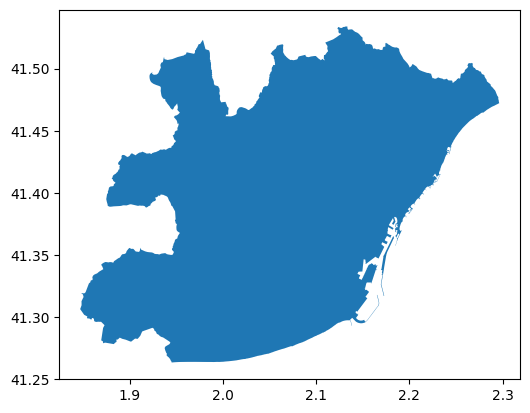

In [2]:
# Importing osmnx

# Define the polygon for the 1st district of Budapest
admin_district = ox.geocode_to_gdf('Àrea Metropolitana de Barcelona, Spain')
admin_district.plot()
admin_poly = admin_district.geometry.values[0]

# Load the graph from OSMnx
G = ox.graph_from_polygon(admin_poly, network_type='walk')

print('Number of intersections: ', G.number_of_nodes())
print('Number of road segments:',  G.number_of_edges())

In [3]:
neigh = pd.read_csv("Data/Neigh/neigh.csv")

neigh["geometry"] = neigh["geom"].apply(wkt.loads)

neigh = gpd.GeoDataFrame(
    neigh,
    geometry="geometry",
    crs="EPSG:4326"
)
neigh = neigh[["name", "geometry"]]
neigh["geometry"] = neigh.buffer(0)


neigh_layer = alt.Chart(neigh).mark_geoshape(
    stroke="black",
    fill="lightblue"
).properties(
    width=600,
    height=600
    
).encode(tooltip=['name'])

In [4]:
bus_sol = pd.read_csv('Nodes/Bus-Sol.csv')
bus = pd.read_csv('Nodes/Bus.csv')
fgc_sol = pd.read_csv('Nodes/FGC-Sol.csv')
fgc = pd.read_csv('Nodes/FGC.csv')
metro_sol = pd.read_csv('Nodes/Metro-Sol.csv')
metro = pd.read_csv('Nodes/Metro.csv')
tram_sol = pd.read_csv('Nodes/Tram-Sol.csv')
tram = pd.read_csv('Nodes/Tram.csv')
destinations = pd.read_csv('Nodes/Destinations.csv')

all_stops = pd.concat([bus_sol, bus, fgc_sol, fgc, metro_sol, metro, tram_sol, tram], ignore_index=True)
all_stops['geometry']= all_stops['geometry'].apply(wkt.loads)
all_stops = gpd.GeoDataFrame(all_stops, geometry='geometry', crs="EPSG:4326")
#all_stops = all_stops[:100]


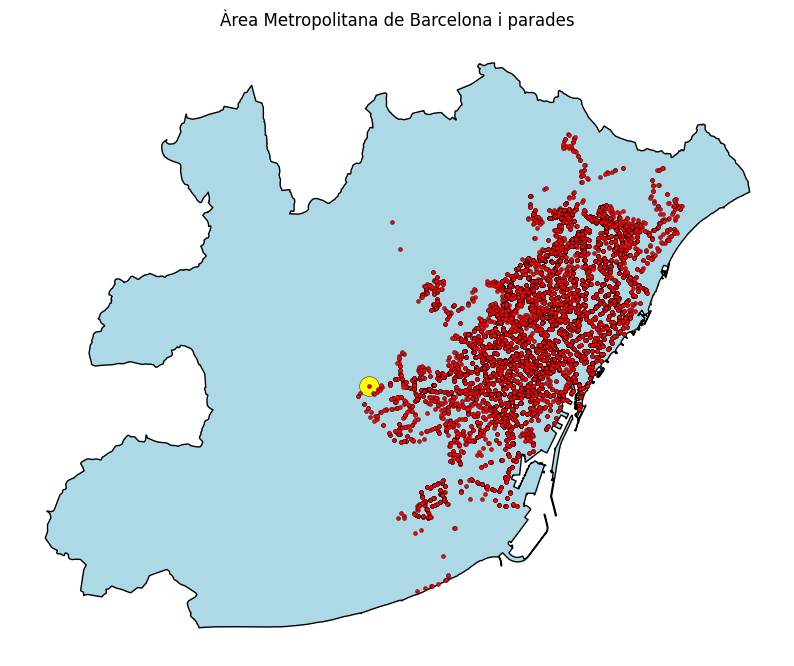

In [5]:
fig, ax = plt.subplots(figsize=(10, 10))

admin_district.plot(
    ax=ax,
    color="lightblue",
    edgecolor="black",
    linewidth=1
)

all_stops[all_stops['stop_id'] == 'CCML'].plot(
    ax=ax,
    color="yellow",
    markersize=200,
    edgecolor="black",
    linewidth=0.3
)

all_stops.plot(
    ax=ax,
    color="red",
    markersize=8,
    edgecolor="black",
    linewidth=0.3
)

ax.set_title("Àrea Metropolitana de Barcelona i parades")
ax.axis("off")
plt.show()

In [6]:
all_stops[all_stops['stop_id'] == 'CCML']

,id,stop_id,name,linia,stop_type,geometry
7787,T-T3-CCML,CCML,Sant Feliu | Consell Comarcal,T3,Tram,POINT (2.05337 41.37936)


In [7]:
walking_speed = 1.39

for u, v, data in G.edges(data=True):
    data["travel_time"] = data["length"] / walking_speed


isochrone_time = 5
isochrone_polys = []

process = 1
for stop in all_stops['stop_id'].unique():
    print(f"Processing stop {stop} ({process}/{len(all_stops['stop_id'].unique())})")

    process += 1
    p = all_stops[all_stops['stop_id'] == stop].iloc[0]
    center_node = ox.distance.nearest_nodes(G, X=p['geometry'].x, Y=p["geometry"].y)

    subgraph = nx.ego_graph(
            G,
            center_node,
            radius= isochrone_time * 60,
            distance="travel_time"
        )

    node_points = [
        Point((data["x"], data["y"]))
        for node, data in subgraph.nodes(data=True)
    ]

    center_point = Point(G.nodes[center_node]["x"], G.nodes[center_node]["y"])

    polygon = gpd.GeoSeries(node_points).union_all().convex_hull
    isochrone_polys.append(
            gpd.GeoDataFrame(
                {"stop_id": [p["stop_id"]], "geometry": [polygon]},
                crs="EPSG:4326"
            )
        )

isochrone_polys = gpd.GeoDataFrame(pd.concat(isochrone_polys, ignore_index=True), crs="EPSG:4326")

Processing stop 2 (1/3330)
Processing stop 3 (2/3330)
Processing stop 4 (3/3330)
Processing stop 7 (4/3330)
Processing stop 8 (5/3330)
Processing stop 12 (6/3330)
Processing stop 13 (7/3330)
Processing stop 15 (8/3330)
Processing stop 16 (9/3330)
Processing stop 17 (10/3330)
Processing stop 18 (11/3330)
Processing stop 20 (12/3330)
Processing stop 21 (13/3330)
Processing stop 22 (14/3330)
Processing stop 24 (15/3330)
Processing stop 25 (16/3330)
Processing stop 27 (17/3330)
Processing stop 28 (18/3330)
Processing stop 29 (19/3330)
Processing stop 30 (20/3330)
Processing stop 31 (21/3330)
Processing stop 32 (22/3330)
Processing stop 34 (23/3330)
Processing stop 36 (24/3330)
Processing stop 38 (25/3330)
Processing stop 39 (26/3330)
Processing stop 41 (27/3330)
Processing stop 42 (28/3330)
Processing stop 43 (29/3330)
Processing stop 44 (30/3330)
Processing stop 47 (31/3330)
Processing stop 48 (32/3330)
Processing stop 51 (33/3330)
Processing stop 52 (34/3330)
Processing stop 54 (35/3330)

In [8]:
isocores_df_all = all_stops[all_stops['stop_id'].isin(isochrone_polys['stop_id'].unique())].merge(isochrone_polys, on='stop_id', how='left')
isocores_df_all.drop(columns=['geometry_x'], inplace=True)
isocores_df_all.rename(columns={'geometry_y': 'geometry'}, inplace=True)
isocores_df_all.set_geometry('geometry', inplace=True)
isocores_df_all

,id,stop_id,name,linia,stop_type,geometry
0,SB-2,2,Av Icària - Àlaba,IU Stop,Bus,"POLYGON ((2.19864 41.39029, 2.19655 41.39061, ..."
1,SB-3,3,València - Muntaner,IU Stop,Bus,"POLYGON ((2.15827 41.38549, 2.15633 41.38565, ..."
2,SB-4,4,Mallorca - Balmes,IU Stop,Bus,"POLYGON ((2.15993 41.38804, 2.15929 41.38809, ..."
3,SB-7,7,Pl Universitat,IU Stop,Bus,"POLYGON ((2.16361 41.38233, 2.15976 41.38319, ..."
4,SB-8,8,Pl de Carles Buïgas,IU Stop,Bus,"POLYGON ((2.15159 41.36902, 2.14665 41.36923, ..."
...,...,...,...,...,...,...
7804,T-T5-STJB,STJB,Sant Joan Baptista,T5,Tram,"POLYGON ((2.22446 41.42451, 2.22411 41.42458, ..."
7805,T-T5-NKNS,NKNS,Encants de Sant Adrià,T5,Tram,"POLYGON ((2.21987 41.42728, 2.21921 41.42804, ..."
7806,T-T5-STRC,STRC,Sant Roc,T5,Tram,"POLYGON ((2.22644 41.43243, 2.22467 41.43269, ..."
7807,T-T5-GORG,GORG,Gorg,T5,Tram,"POLYGON ((2.23004 41.43745, 2.22926 41.43984, ..."


In [9]:
test = all_stops.copy()
isocores_df_all_merge = isocores_df_all.copy()
test.to_crs('EPSG:25831', inplace=True)
isocores_df_all_merge.to_crs('EPSG:25831', inplace=True)
test.rename(columns={'id': 'destination_id','stop_id':'destination_stop_id','name':'destination_stop_name','linia':'destination_linia','stop_type':'destination_stop_type'}, inplace=True)
isocores_df_all_merge.rename(columns={'id': 'origin_id','stop_id':'origin_stop_id','name':'origin_stop_name','linia':'origin_linia','stop_type':'origin_stop_type'}, inplace=True)
close_stops = gpd.sjoin(test[test['destination_id'].isin(isocores_df_all_merge['origin_id'])], isocores_df_all_merge, how='inner', predicate='within')
close_stops = close_stops[close_stops['origin_id'] != close_stops['destination_id']]
close_stops = close_stops[~close_stops['destination_id'].str.startswith('S')]
close_stops = close_stops[['origin_id', 'origin_stop_id', 'origin_stop_type', 'origin_stop_name', 'origin_linia', 'destination_id', 'destination_stop_id', 'destination_stop_type', 'destination_stop_name', 'destination_linia']]
close_stops['tram'] = close_stops['origin_stop_name'] + ' - ' + close_stops['destination_stop_name']
close_stops['mode'] = close_stops['origin_stop_type'] + ' - ' + close_stops['destination_stop_type']
close_stops['lines'] = close_stops['origin_linia'] + ' - ' + close_stops['destination_linia']
close_stops.drop(columns=['origin_stop_name', 'destination_stop_name','origin_linia','destination_linia'], inplace=True)
close_stops

,origin_id,origin_stop_id,origin_stop_type,destination_id,destination_stop_id,destination_stop_type,tram,mode,lines
1631,SB-2,2,Bus,B-59-2,2,Bus,Av Icària - Àlaba - Av Icària - Àlaba,Bus - Bus,IU Stop - 59
1631,SB-34,34,Bus,B-59-2,2,Bus,Av Icària - Av Bogatell - Av Icària - Àlaba,Bus - Bus,IU Stop - 59
1631,SB-342,342,Bus,B-59-2,2,Bus,Cementiri de l'Est - Av Icària - Àlaba,Bus - Bus,IU Stop - 59
1631,SB-682,682,Bus,B-59-2,2,Bus,Cementiri de l'Est - Av Icària - Àlaba,Bus - Bus,IU Stop - 59
1631,SB-698,698,Bus,B-59-2,2,Bus,Av Icària - Joan Miró - Av Icària - Àlaba,Bus - Bus,IU Stop - 59
...,...,...,...,...,...,...,...,...,...
7808,B-V33-3596,3596,Bus,T-T6-MINA,MINA,Tram,La Mina - Ponent - La Mina,Bus - Tram,V33 - T6
7808,B-B23-105999,105999,Bus,T-T6-MINA,MINA,Tram,Rambla de la Mina - La Mina,Bus - Tram,B23 - T6
7808,B-B23-106000,106000,Bus,T-T6-MINA,MINA,Tram,CAP La Mina - La Mina,Bus - Tram,B23 - T6
7808,T-T5-PARC,PARC,Tram,T-T6-MINA,MINA,Tram,Parc del Besòs - La Mina,Tram - Tram,T5 - T6


In [10]:
same_stops = close_stops[
    (close_stops['origin_stop_id'] == close_stops['destination_stop_id']) & (close_stops['origin_stop_type'] == close_stops['destination_stop_type'])
].copy()
same_stops = same_stops.drop(columns=['origin_stop_id', 'destination_stop_id'])

conditions = [
    same_stops['origin_id'].str.startswith('S', na=False) & same_stops['destination_id'].str.startswith(('M', 'F'), na=False),
    same_stops['origin_id'].str.startswith('S', na=False) & same_stops['destination_id'].str.startswith('B', na=False),
    same_stops['origin_id'].str.startswith('S', na=False) & same_stops['destination_id'].str.startswith('T', na=False),
    same_stops['origin_id'].str.startswith('B', na=False) & same_stops['destination_id'].str.startswith('B', na=False),
    same_stops['origin_id'].str.startswith(('M', 'F'), na=False) & same_stops['destination_id'].str.startswith(('M', 'F'), na=False),
    same_stops['origin_id'].str.startswith('T', na=False) & same_stops['destination_id'].str.startswith('T', na=False),

]
choices = [3, 1, 2, 1, 2, 1]
same_stops['type'] = 'Exchange - Self'
same_stops['time'] = np.select(conditions, choices, default=0)
# same_stops['time'] = pd.to_timedelta(
#     np.select(conditions, choices, default=0),
#     unit='m'
# )

# same_stops['time'] = same_stops['time'].apply(
#     lambda x: f"{int(x.total_seconds() // 60):02d}:{int(x.total_seconds() % 60):02d}"
# )
same_stops['geometry'] = same_stops.apply(lambda row: all_stops.loc[all_stops['id'] == row['origin_id'], 'geometry'].values[0], axis=1)
same_stops.drop(columns=['origin_stop_type', 'destination_stop_type'], inplace=True)
same_stops


,origin_id,destination_id,tram,mode,lines,type,time,geometry
1631,SB-2,B-59-2,Av Icària - Àlaba - Av Icària - Àlaba,Bus - Bus,IU Stop - 59,Exchange - Self,1,POINT (2.198984998801282 41.393104003754864)
1631,B-H16-2,B-59-2,Av Icària - Àlaba - Av Icària - Àlaba,Bus - Bus,H16 - 59,Exchange - Self,1,POINT (2.198984998801282 41.393104003754864)
1631,B-V27-2,B-59-2,Av Icària - Àlaba - Av Icària - Àlaba,Bus - Bus,V27 - 59,Exchange - Self,1,POINT (2.198984998801282 41.393104003754864)
1632,SB-2,B-H16-2,Av Icària - Àlaba - Av Icària - Àlaba,Bus - Bus,IU Stop - H16,Exchange - Self,1,POINT (2.198984998801282 41.393104003754864)
1632,B-59-2,B-H16-2,Av Icària - Àlaba - Av Icària - Àlaba,Bus - Bus,59 - H16,Exchange - Self,1,POINT (2.198984998801282 41.393104003754864)
...,...,...,...,...,...,...,...,...
7799,T-T6-ALFS,T-T5-ALFS,Alfons el Magnànim - Alfons el Magnànim,Tram - Tram,T6 - T5,Exchange - Self,1,POINT (2.213568925857544 41.41719055175781)
7800,ST-ALFS,T-T6-ALFS,Alfons el Magnànim - Alfons el Magnànim,Tram - Tram,IU Stop - T6,Exchange - Self,2,POINT (2.213568925857544 41.41719055175781)
7800,T-T5-ALFS,T-T6-ALFS,Alfons el Magnànim - Alfons el Magnànim,Tram - Tram,T5 - T6,Exchange - Self,1,POINT (2.213568925857544 41.41719055175781)
7801,T-T6-PARC,T-T5-PARC,Parc del Besòs - Parc del Besòs,Tram - Tram,T6 - T5,Exchange - Self,1,POINT (2.217633008956909 41.419429779052734)


In [11]:
# cache_dir = Config().CACHE_DIR
# for f in cache_dir.glob("*.mapdb*"):
#     f.unlink()

In [12]:
transport_network = r5py.TransportNetwork(
    "Data/Neigh/cataluna-260811.osm.pbf",
    elevation_model =["Data/Neigh/elevacions-terreny-lidar-Catalunya-2m-2008-2011tif1786456535055.tif"]
    )

In [13]:
itineraries = pd.DataFrame()
process = 0
failed_iteraries = []
different_stops = close_stops[
    (close_stops['origin_stop_id'] != close_stops['destination_stop_id'])
]


for stop in different_stops['origin_stop_id'].unique():
    process += 1
    print(f"Processing {process}/{different_stops['origin_stop_id'].nunique()}")
    stops = different_stops[different_stops['origin_stop_id'] == stop]
    stops.drop_duplicates(subset=['origin_stop_id', 'destination_stop_id'], inplace=True)

    for _, row in stops.iterrows():
        origin_id = row['origin_stop_id']
        destination_id = row['destination_stop_id']

        # if origin_id  != 1323:
        #     continue
        # if destination_id != 2:
        #     continue

        # if process != 2374:
        #     continue

        origins = all_stops[all_stops['stop_id'] == origin_id].copy()
        origins.drop_duplicates(subset=['stop_id'], inplace=True)
        destinations = all_stops[all_stops['stop_id'] == destination_id].copy()
        destinations.drop_duplicates(subset=['stop_id'], inplace=True)
        origins.rename(columns={'origin_id': 'id'}, inplace=True)
        destinations.rename(columns={'destination_id': 'id'}, inplace=True)
        origins = gpd.GeoDataFrame(origins, geometry='geometry', crs="EPSG:4326")
        destinations = gpd.GeoDataFrame(destinations, geometry='geometry', crs="EPSG:4326")
        detailed_itineraries = r5py.DetailedItineraries(
            transport_network,
            origins=origins,
            destinations=destinations,
            transport_modes=[r5py.TransportMode.WALK],
            snap_to_network=True,
            speed_walking = 5,
            departure=datetime.datetime(2026, 5, 13, 9, 30),

        )

        if len(detailed_itineraries) == 0:
            failed_iteraries.append((origin_id, destination_id))
            continue
        exchange_time = detailed_itineraries['travel_time'].sum()
        itineraries_row = pd.DataFrame({
            'origin_stop_id': [origin_id],
            'destination_stop_id': [destination_id],
            'time': [exchange_time],
            'geometry': [detailed_itineraries['geometry'].iloc[0]],
        })

        itineraries_row = gpd.GeoDataFrame(itineraries_row, geometry='geometry', crs="EPSG:4326")
        itineraries = pd.concat([itineraries, itineraries_row], ignore_index=True)


itineraries["time"] = itineraries["time"].apply(
    lambda x: x.total_seconds() / 60
)


Processing 1/3272
Processing 2/3272
Processing 3/3272
Processing 4/3272
Processing 5/3272
Processing 6/3272
Processing 7/3272
Processing 8/3272
Processing 9/3272
Processing 10/3272
Processing 11/3272
Processing 12/3272
Processing 13/3272
Processing 14/3272
Processing 15/3272
Processing 16/3272
Processing 17/3272
Processing 18/3272
Processing 19/3272
Processing 20/3272
Processing 21/3272
Processing 22/3272
Processing 23/3272
Processing 24/3272
Processing 25/3272
Processing 26/3272
Processing 27/3272
Processing 28/3272
Processing 29/3272
Processing 30/3272
Processing 31/3272
Processing 32/3272
Processing 33/3272
Processing 34/3272
Processing 35/3272
Processing 36/3272
Processing 37/3272
Processing 38/3272
Processing 39/3272
Processing 40/3272
Processing 41/3272
Processing 42/3272
Processing 43/3272
Processing 44/3272
Processing 45/3272
Processing 46/3272
Processing 47/3272
Processing 48/3272
Processing 49/3272
Processing 50/3272
Processing 51/3272
Processing 52/3272
Processing 53/3272
Pr

In [14]:
different_stops_final = different_stops.merge(itineraries, on=['origin_stop_id', 'destination_stop_id'], how='left')
different_stops_final.drop(columns=['origin_stop_id', 'destination_stop_id','destination_stop_type','origin_stop_type'], inplace=True)
different_stops_final.insert(5, 'type', 'Exchange')
different_stops_final = different_stops_final[different_stops_final['geometry'].notnull()]

In [17]:
all_exchanges = pd.concat([same_stops, different_stops_final], ignore_index=True)
all_exchanges.rename(columns={'origin_id': 'origen', 'destination_id': 'dest','exchange_time':'time'}, inplace=True)
#all_exchanges = gpd.GeoDataFrame(all_exchanges, geometry='geometry', crs="EPSG:4326")
all_exchanges = all_exchanges[all_exchanges['time'] <= 5]
all_exchanges.insert(7, 'directed', True)

In [19]:
all_exchanges.to_csv('Edges/Exchanges.csv', index=False)

In [20]:
# Frame 1: polygons only
isochrone_chart = alt.Chart(isocores_df_all[isocores_df_all['stop_id'].isin([2575])]).mark_geoshape(
    stroke='black',
    strokeWidth=1
).encode(tooltip=['id'])

points = alt.Chart(all_stops[all_stops['stop_id'].isin([2575,84])]).mark_geoshape(
    fill='red',
    stroke='black',
    strokeWidth=1,
    size=0
).encode(
    tooltip=['name']
)

itineraries_chart = alt.Chart(all_exchanges[all_exchanges['origen'].isin(['B-B80-2575']) & (all_exchanges['dest'].isin(['B-B18-84']))]).mark_geoshape(
    filled = False,
    stroke='black',
    strokeWidth=1,
    size=0
)


(
isochrone_chart + points + itineraries_chart  ).properties(
    width=900,
    height=900
)

TypeError: Object of type MultiLineString is not JSON serializable

alt.LayerChart(...)

In [ ]:
# Frame 1: polygons only
polys_df = isocores_df_all[['id', 'geometry']].copy()
polys_df = gpd.GeoDataFrame(polys_df, geometry='geometry', crs="EPSG:4326")


not_self_exchanges = all_exchanges[all_exchanges['type'] == 'Exchange'].copy()
#not_self_exchanges = not_self_exchanges[not_self_exchanges['mode'] == 'Bus - Tram']
origens = not_self_exchanges['origen'].unique().tolist()
destinations = not_self_exchanges['dest'].unique().tolist()
stops =  origens + destinations

isochrone_chart = alt.Chart(polys_df[polys_df['id'].isin(origens)]).mark_geoshape(
    stroke='black',
    strokeWidth=1
).encode(tooltip=['id'])

points = alt.Chart(all_stops[all_stops['id'].isin(stops)]).mark_geoshape(
    fill='red',
    stroke='black',
    strokeWidth=1,
    size=0
).encode(
    tooltip=['name']
)

itineraries_chart = alt.Chart(not_self_exchanges).mark_geoshape(
    filled = False,
    stroke='black',
    strokeWidth=1,
    size=0
)


(
neigh_layer + isochrone_chart).properties(
    width=900,
    height=900
)

MaxRowsError: The number of rows in your dataset (8390) is greater than the maximum allowed (5000).

Try enabling the VegaFusion data transformer which raises this limit by pre-evaluating data
transformations in Python.
    >> import altair as alt
    >> alt.data_transformers.enable("vegafusion")

Or, see https://altair-viz.github.io/user_guide/large_datasets.html for additional information
on how to plot large datasets.

alt.LayerChart(...)

In [ ]:



# ---------------------------------------------------------
# Load neighbourhoods
# ---------------------------------------------------------

neigh = pd.read_csv("Data/Neigh/neigh.csv")

neigh["geometry"] = neigh["geom"].apply(wkt.loads)

neigh = gpd.GeoDataFrame(
    neigh,
    geometry="geometry",
    crs="EPSG:4326"
)

neigh = neigh[["name", "geometry"]]

neigh["geometry"] = neigh.geometry.buffer(0)


# ---------------------------------------------------------
# Prepare itinerary data
# ---------------------------------------------------------

itineraries["mode"] = itineraries["transport_mode"].astype(str)

itineraries["travel time (min)"] = itineraries["travel_time"].apply(
    lambda t: round(t.total_seconds() / 60.0, 2)
)

itineraries["trip"] = itineraries.apply(
    lambda row: f"{row['from_id']} → {row['to_id']}",
    axis=1
)


# ---------------------------------------------------------
# Create map
# ---------------------------------------------------------



detailed_routes_map = (
    itineraries[
        [
            "geometry",
            "distance",
            "mode",
            "travel time (min)",
            "from_id",
            "to_id",
            "trip",
            "option",
            "segment",
        ]
    ]
    .explore(
        tooltip=[
            "trip",
            "option",
            "segment",
            "mode",
            "travel time (min)",
            "distance",
        ],
        column="mode",
        tiles="CartoDB.Positron",
        style_kwds={
            "weight": 3,
            "opacity": 0.8,
        },
        highlight_kwds={
            "weight": 6,
            "opacity": 1,
        },
    )
)


isochrone_polys.explore(
    m=detailed_routes_map,
    tooltip=["stop_id"],
    style_kwds={
        "fillOpacity": 0.15,
        "weight": 1,
    },
)

# ---------------------------------------------------------
# Get stops involved in the itineraries
# ---------------------------------------------------------

stop_ids = pd.unique(
    pd.concat([
        itineraries["from_id"],
        itineraries["to_id"]
    ])
)

stops_map = all_stops[
    all_stops["id"].isin(stop_ids)
].copy()

stops_map = gpd.GeoDataFrame(
    stops_map,
    geometry="geometry",
    crs="EPSG:4326"
)


# ---------------------------------------------------------
# Assign neighbourhood to each stop
# ---------------------------------------------------------

# Project both layers for the spatial join
stops_projected = stops_map.to_crs("EPSG:25831")
neigh_projected = neigh.to_crs("EPSG:25831")

stops_map = gpd.sjoin(
    stops_projected,
    neigh_projected[["name", "geometry"]],
    how="left",
    predicate="within"
)

# Return to WGS84 for Folium
stops_map = stops_map.to_crs("EPSG:4326")


# ---------------------------------------------------------
# Add stop markers
# ---------------------------------------------------------

stops_map.apply(
    lambda row: folium.Marker(
        location=[
            row.geometry.y,
            row.geometry.x
        ],
        tooltip=(
            f"Stop: {row['id']}<br>"
        ),
        icon=folium.plugins.BeautifyIcon(
            icon_shape="marker",
            number=str(row["id"]),
            border_color="#728224",
            text_color="#728224",
        ),
    ).add_to(detailed_routes_map),
    axis=1,
)


detailed_routes_map